Environment ready!
NumPy: 2.5.1
Pandas: 3.0.3
Scikit-learn: 1.9.0

First 5 rows:
                         movie_title mcu_phase release_date  tomato_meter  \
0                           Iron Man   Phase 1   2008-05-02            94   
1                The Incredible Hulk   Phase 1   2008-06-13            67   
2                         Iron Man 2   Phase 1   2010-05-07            72   
3                               Thor   Phase 1   2011-05-06            77   
4  Captain America The First Avenger   Phase 1   2011-07-22            80   

   audience_score  movie_duration  production_budget  opening_weekend  \
0              91           126.0        140000000.0      102118668.0   
1              70           112.0        137500000.0       55414050.0   
2              71           124.0        200000000.0      128122480.0   
3              76           114.0        150000000.0       65723338.0   
4              75           124.0        140000000.0       65058524.0   

   domestic_box_o

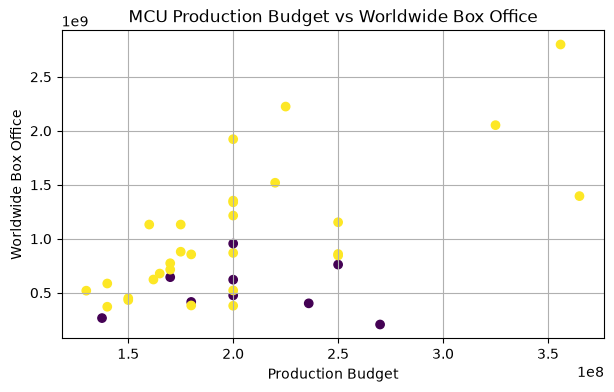


X shape: (62, 4)
y shape: (62,)

Training rows: 49
Testing rows : 13

Model trained!

Accuracy: 0.6923076923076923

Confusion Matrix:
[[1 2]
 [2 8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.80      0.80      0.80        10

    accuracy                           0.69        13
   macro avg       0.57      0.57      0.57        13
weighted avg       0.69      0.69      0.69        13



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ------------------------------------------
# 1. Check Environment
# ------------------------------------------

print("Environment ready!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)


# ------------------------------------------
# 2. Load MCU Dataset
# ------------------------------------------

df = pd.read_csv("mcu.csv")

print("\nFirst 5 rows:")
print(df.head())


# ------------------------------------------
# 3. Create Classification Target
# ------------------------------------------

# Movies with Tomato Meter >= 75 are classified as High Rated
df["rating"] = (df["tomato_meter"] >= 75).astype(int)

print("\nRating distribution:")
print(df["rating"].value_counts())


# ------------------------------------------
# 4. Group Data by Rating
# ------------------------------------------

print("\nAverage MCU Movie Statistics by Rating:")

print(
    df.groupby("rating")[[
        "audience_score",
        "movie_duration",
        "production_budget",
        "opening_weekend"
    ]].mean()
)


# ------------------------------------------
# 5. Visualize Movie Performance
# ------------------------------------------

plt.figure(figsize=(7, 4))

plt.scatter(
    df["production_budget"],
    df["worldwide_box_office"],
    c=df["rating"]
)

plt.xlabel("Production Budget")
plt.ylabel("Worldwide Box Office")
plt.title("MCU Production Budget vs Worldwide Box Office")

plt.grid(True)
plt.show()


# ------------------------------------------
# 6. Select Features and Target
# ------------------------------------------

X = df[[
    "audience_score",
    "movie_duration",
    "production_budget",
    "opening_weekend"
]]

y = df["rating"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ------------------------------------------
# 7. Split Dataset
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))


# ------------------------------------------
# 8. Create Decision Tree
# ------------------------------------------

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel trained!")


# ------------------------------------------
# 9. Make Predictions
# ------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------
# 10. Evaluate Model
# ------------------------------------------

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

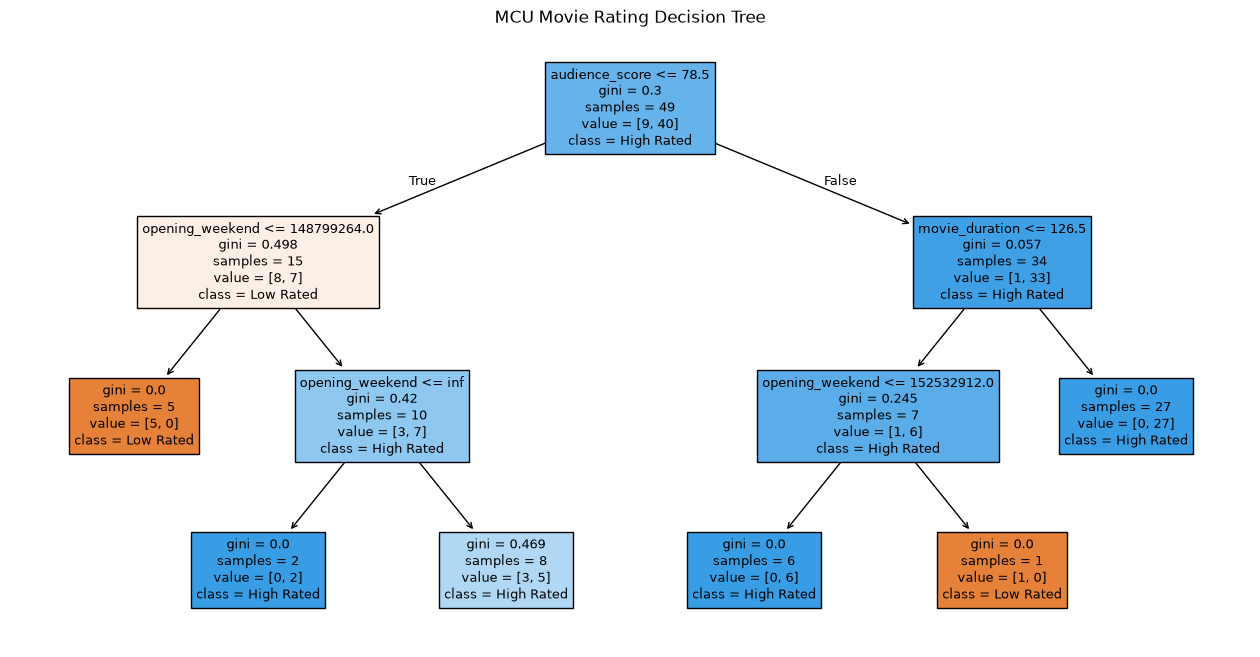

In [2]:
plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low Rated", "High Rated"],
    filled=True
)

plt.title("MCU Movie Rating Decision Tree")
plt.show()